In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

data = pd.read_csv("C:/Users/MehmetSalih/Desktop/creditcard.csv")

df = data.copy()

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

scaler = RobustScaler()
X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_val[['Amount', 'Time']] = scaler.transform(X_val[['Amount', 'Time']])
X_test[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

neg, pos = np.bincount(y_train)
ratio = neg / pos

**Öncelikle gerekli kütüphanelerin içe aktarılması ve veri setinin özellik değişkenlerine ayrılmaktadır. Veri seti, dolandırıcılık vakalarının azınlıkta olması sebebiyle stratify parametresi eşliğinde eğitim, doğrulama ve test kümelerine bölünerek her aşamada sınıf dengesi korunmakta.Ardından "Amount" ve "Time" gibi değişkenler aykırı değerlere karşı dirençli olan RobustScaler ile normalize edilmektedir. Son olarak hesaplanan neg/pos oranı, özellikle XGBoost gibi modellerde dengesiz veri setine karşı ağırlıklandırma yapmak ve azınlık sınıfı olan dolandırıcılık vakalarının daha hassas yakalanmasını sağlamak amacıyla kullanılmaktadır.**

In [10]:
# --- RANDOM FOREST ---
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced_subsample', 
    random_state=42,
    n_jobs=-1
)

# --- XGBOOST ---
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    early_stopping_rounds=10,
    random_state=42
)

print("Modeller eğitiliyor...")


rf_model.fit(X_train, y_train)
print("Random Forest Validasyon Sonuçları:")
print(classification_report(y_val, rf_model.predict(X_val)))

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=10
)
print("XGBoost Validasyon Sonuçları:")
print(classification_report(y_val, xgb_model.predict(X_val)))

print("Eğitim tamamlandı.")


Modeller eğitiliyor...
Random Forest Validasyon Sonuçları:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42647
           1       0.79      0.74      0.76        74

    accuracy                           1.00     42721
   macro avg       0.89      0.87      0.88     42721
weighted avg       1.00      1.00      1.00     42721

[0]	validation_0-aucpr:0.60487	validation_1-aucpr:0.43310
[10]	validation_0-aucpr:0.79490	validation_1-aucpr:0.57708
[20]	validation_0-aucpr:0.86851	validation_1-aucpr:0.63961
[30]	validation_0-aucpr:0.88290	validation_1-aucpr:0.65025
[40]	validation_0-aucpr:0.94044	validation_1-aucpr:0.76432
[50]	validation_0-aucpr:0.95844	validation_1-aucpr:0.78360
[60]	validation_0-aucpr:0.98390	validation_1-aucpr:0.79859
[70]	validation_0-aucpr:0.98871	validation_1-aucpr:0.80558
[80]	validation_0-aucpr:0.99302	validation_1-aucpr:0.81901
[90]	validation_0-aucpr:0.99688	validation_1-aucpr:0.82352
[99]	validation_0-aucpr:0

**Projenin  modelleme aşamasını oluşturarak Random Forest ve XGBoost algoritmalarının yapılandırılmasını ve eğitim sürecini kapsamaktadır. Random Forest modelinde ***class_weight='balanced_subsample'*** parametresi kullanılarak her ağaç oluşturulurken verideki sınıf dengesizliği otomatik olarak telafi edilmekte, XGBoost tarafında ise önceden hesaplanan ratio değeri ***scale_pos_weight*** parametresine atanarak modelin dolandırıcılık vakalarına daha hassas yaklaşması sağlanmaktadır**


========== Random Forest İÇİN OPTİMİZASYON ==========
En İyi Eşik Değeri (Threshold): 0.5299
Optimize Edilmiş F1 Skoru:    0.8369
----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.88      0.80      0.84        74

    accuracy                           1.00     42722
   macro avg       0.94      0.90      0.92     42722
weighted avg       1.00      1.00      1.00     42722


========== XGBoost İÇİN OPTİMİZASYON ==========
En İyi Eşik Değeri (Threshold): 0.8775
Optimize Edilmiş F1 Skoru:    0.8489
----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.91      0.80      0.85        74

    accuracy                           1.00     42722
   macro avg       0.95      0.90      0.92     42722
weighted avg       1.00      1.00      1.00     42722



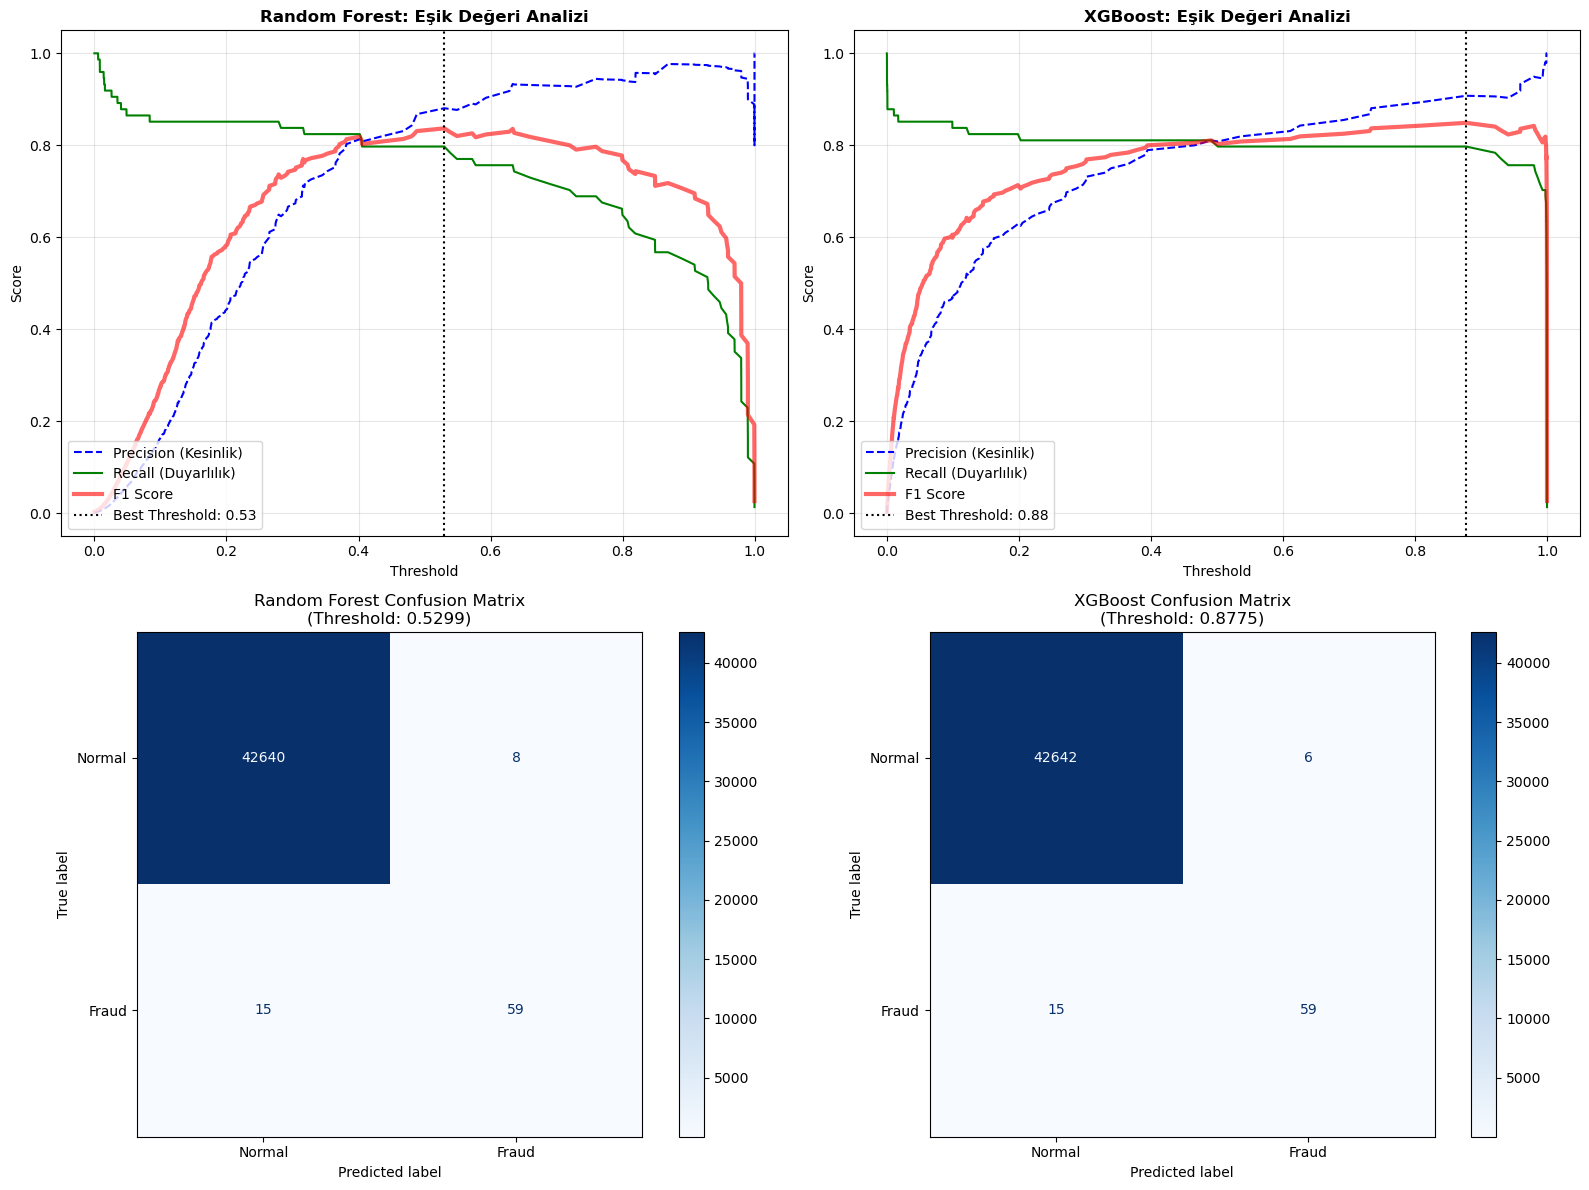

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, classification_report
import numpy as np

# Modelleri listeye alalım
models = {'Random Forest': rf_model, 'XGBoost': xgb_model}

# 2 Satır, 2 Sütunluk bir alan açıyoruz (Üstte grafikler, altta matrisler)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, (name, model) in enumerate(models.items()):
    
    # --- 1. Hesaplamalar ---
    y_probs = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    
    # F1 Skoru hesaplama
    numerator = 2 * recall * precision
    denominator = recall + precision
    f1_scores = np.divide(numerator, denominator, out=np.zeros_like(denominator), where=denominator!=0)
    
    # En iyi F1 skorunun olduğu indexi bul
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    # Yeni eşik değerine göre tahminler
    y_pred_new = (y_probs >= best_thresh).astype(int)
    
    # --- Konsol Çıktısı ---
    print(f"\n{'='*10} {name} İÇİN OPTİMİZASYON {'='*10}")
    print(f"En İyi Eşik Değeri (Threshold): {best_thresh:.4f}")
    print(f"Optimize Edilmiş F1 Skoru:    {best_f1:.4f}")
    print("-" * 40)
    print(classification_report(y_test, y_pred_new))

    # --- 2. ÜST GRAFİK: Precision-Recall-F1 Eğrileri ---
    ax_curve = axes[0, i] # 0. Satırın i. Sütunu
    
    ax_curve.plot(thresholds, precision[:-1], 'b--', label='Precision (Kesinlik)')
    ax_curve.plot(thresholds, recall[:-1], 'g-', label='Recall (Duyarlılık)')
    ax_curve.plot(thresholds, f1_scores[:-1], 'r', alpha=0.6, linewidth=3, label='F1 Score')
    
    # En iyi noktayı işaretle
    ax_curve.axvline(best_thresh, color='black', linestyle=':', label=f'Best Threshold: {best_thresh:.2f}')
    ax_curve.set_title(f"{name}: Eşik Değeri Analizi", fontsize=12, fontweight='bold')
    ax_curve.set_xlabel("Threshold")
    ax_curve.set_ylabel("Score")
    ax_curve.legend(loc='lower left')
    ax_curve.grid(True, alpha=0.3)
    
    # --- 3. ALT GRAFİK: Confusion Matrix ---
    ax_matrix = axes[1, i] # 1. Satırın i. Sütunu
    
    cm = confusion_matrix(y_test, y_pred_new)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
    
    disp.plot(ax=ax_matrix, cmap='Blues', values_format='d')
    ax_matrix.set_title(f"{name} Confusion Matrix\n(Threshold: {best_thresh:.4f})", fontsize=12)
    ax_matrix.grid(False) # Matris üzerinde grid çizgilerini kapat

plt.tight_layout()
plt.show()